<a href="https://colab.research.google.com/github/springboardmentor1234r/B13-AirFly-Insights-Internship/blob/nikhil_adduri_branch/AirFly_Insights_Nikhil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Milestone 1 – Week 1: Data Foundation and Cleaning**



**Dataset: Flight Delay & Cancellation (2019–2023)**

**STEP 1: Import Required Libraries**

In [ ]:
# Step 1: Install & Import Libraries
!pip install plotly --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [ ]:
# checking  installaion

import plotly
print("Plotly installed successfully")

Plotly installed successfully


**STEP 2: Create Project Folder Structure**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**STEP 3: Confirm Dataset Already Loaded**

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/AirFly_Insights_Data_Set.csv', on_bad_lines='skip')

print(f"DataFrame shape: {df.shape}")
print("First 5 rows of the DataFrame:")
display(df.head())

DataFrame shape: (3000000, 32)
First 5 rows of the DataFrame:


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


**DATASET UNDERSTANDING**

STEP 4: Check Dataset Size

The dataset contains ___ rows and ___ columns representing airline operational records.

In [ ]:
df.shape

(3000000, 32)

**STEP 5: Check Column Names**

In [ ]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

**SCHEMA ANALYSIS**

**STEP 6: Check Data Types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

object → categorical

int/float → numerical

object but looks like date → needs conversion

**STEP 7: Separate Column Types**

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'ORIGIN',
       'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CANCELLATION_CODE'],
      dtype='object')

Numerical Columns:
Index(['DOT_CODE', 'FL_NUMBER', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY',
       'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME',
       'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')


**STEP 8: Create Feature Dictionary**

In [ ]:
feature_dictionary = pd.DataFrame({
    "Column_Name": df.columns,
    "Data_Type": df.dtypes.values,
    "Null_Count": df.isnull().sum().values
})

feature_dictionary

,Column_Name,Data_Type,Null_Count
0,FL_DATE,object,0
1,AIRLINE,object,0
2,AIRLINE_DOT,object,0
3,AIRLINE_CODE,object,0
4,DOT_CODE,int64,0
5,FL_NUMBER,int64,0
6,ORIGIN,object,0
7,ORIGIN_CITY,object,0
8,DEST,object,0
9,DEST_CITY,object,0


In [ ]:
import os

# Create the directory if it does not exist
os.makedirs("AirFly_Insights/reports", exist_ok=True)

feature_dictionary.to_csv("AirFly_Insights/reports/feature_dictionary.csv", index=False)

It documents:

Column name

Data type

Missing values

**MISSING VALUE STUDY**

**STEP 9: Check Null Counts**

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
CANCELLATION_CODE,2920860
DELAY_DUE_LATE_AIRCRAFT,2466137
DELAY_DUE_CARRIER,2466137
DELAY_DUE_SECURITY,2466137
DELAY_DUE_NAS,2466137
DELAY_DUE_WEATHER,2466137
ARR_DELAY,86198
ELAPSED_TIME,86198
AIR_TIME,86198
WHEELS_ON,79944


**STEP 10: Calculate Null Percentage**

In [ ]:
null_percentage = (df.isnull().sum() / len(df)) * 100
null_percentage = null_percentage.sort_values(ascending=False)

null_percentage

,0
CANCELLATION_CODE,97.362000
DELAY_DUE_LATE_AIRCRAFT,82.204567
DELAY_DUE_CARRIER,82.204567
DELAY_DUE_SECURITY,82.204567
DELAY_DUE_NAS,82.204567
DELAY_DUE_WEATHER,82.204567
ARR_DELAY,2.873267
ELAPSED_TIME,2.873267
AIR_TIME,2.873267
WHEELS_ON,2.664800


**STEP 11: Create Null Analysis Report**

In [ ]:
null_report = pd.DataFrame({
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().sum() / len(df)) * 100
})

null_report = null_report.sort_values(by="Null_Percentage", ascending=False)

null_report

,Null_Count,Null_Percentage
CANCELLATION_CODE,2920860,97.362000
DELAY_DUE_LATE_AIRCRAFT,2466137,82.204567
DELAY_DUE_CARRIER,2466137,82.204567
DELAY_DUE_SECURITY,2466137,82.204567
DELAY_DUE_NAS,2466137,82.204567
DELAY_DUE_WEATHER,2466137,82.204567
ARR_DELAY,86198,2.873267
ELAPSED_TIME,86198,2.873267
AIR_TIME,86198,2.873267
WHEELS_ON,79944,2.664800


In [ ]:
null_report.to_csv("AirFly_Insights/reports/null_analysis_report.csv")

**SAMPLING & OPTIMIZATION**

**STEP 12: Check Memory Usage**

In [ ]:
df.memory_usage(deep=True).sum() / (1024**2)

np.float64(1990.9640283584595)

**STEP 13: Optimize Memory (Convert Object → Category)**

In [ ]:
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [ ]:
df.memory_usage(deep=True).sum() / (1024**2)

np.float64(566.7607955932617)

**STEP 14: Create Sample Dataset (10%)**

In [ ]:
sample_df = df.sample(frac=0.1, random_state=42)
sample_df.shape

(300000, 32)

In [ ]:
import os

# Create the directory if it does not exist
os.makedirs("AirFly_Insights/data/sample", exist_ok=True)

sample_df.to_csv("AirFly_Insights/data/sample/sample_dataset.csv", index=False)

In [ ]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,2.920058e+06,2.913802e+06,3.000000e+06,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,1.466511e+03,4.260858e+00,2.638000e-02,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,5.318383e+02,5.117482e+01,1.602626e-01,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,1.053000e+03,-1.600000e+01,0.000000e+00,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,1.505000e+03,-7.000000e+00,0.000000e+00,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,1.913000e+03,7.000000e+00,0.000000e+00,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,2.400000e+03,2.934000e+03,1.000000e+00,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


In [ ]:
null_report = df.isnull().sum().sort_values(ascending=False)
null_report

,0
CANCELLATION_CODE,2920860
DELAY_DUE_LATE_AIRCRAFT,2466137
DELAY_DUE_CARRIER,2466137
DELAY_DUE_SECURITY,2466137
DELAY_DUE_NAS,2466137
DELAY_DUE_WEATHER,2466137
ARR_DELAY,86198
ELAPSED_TIME,86198
AIR_TIME,86198
WHEELS_ON,79944


In [ ]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent.sort_values(ascending=False)

,0
CANCELLATION_CODE,97.362000
DELAY_DUE_LATE_AIRCRAFT,82.204567
DELAY_DUE_CARRIER,82.204567
DELAY_DUE_SECURITY,82.204567
DELAY_DUE_NAS,82.204567
DELAY_DUE_WEATHER,82.204567
ARR_DELAY,2.873267
ELAPSED_TIME,2.873267
AIR_TIME,2.873267
WHEELS_ON,2.664800


In [ ]:
null_percent.to_csv("null_analysis_report.csv")


In [ ]:
df.isnull().sum().sort_values(ascending=False)
(df.isnull().sum()/len(df)) * 100

,0
FL_DATE,0.000000
AIRLINE,0.000000
AIRLINE_DOT,0.000000
AIRLINE_CODE,0.000000
DOT_CODE,0.000000
FL_NUMBER,0.000000
ORIGIN,0.000000
ORIGIN_CITY,0.000000
DEST,0.000000
DEST_CITY,0.000000


In [ ]:
df.duplicated().sum()
df=df.drop_duplicates()


In [ ]:
df.memory_usage(deep=True)

,0
Index,132
FL_DATE,6166624
AIRLINE,3001774
AIRLINE_DOT,3001846
AIRLINE_CODE,3001474
DOT_CODE,24000000
FL_NUMBER,24000000
ORIGIN,6028056
ORIGIN_CITY,6031717
DEST,6028056


In [ ]:
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].astype('category')

for col in df.select_dtypes(include=['int64']).columns:
  df[col]=pd.to_numeric(df[col],downcast='integer')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype   
---  ------                   -----   
 0   FL_DATE                  category
 1   AIRLINE                  category
 2   AIRLINE_DOT              category
 3   AIRLINE_CODE             category
 4   DOT_CODE                 int16   
 5   FL_NUMBER                int16   
 6   ORIGIN                   category
 7   ORIGIN_CITY              category
 8   DEST                     category
 9   DEST_CITY                category
 10  CRS_DEP_TIME             int16   
 11  DEP_TIME                 float64 
 12  DEP_DELAY                float64 
 13  TAXI_OUT                 float64 
 14  WHEELS_OFF               float64 
 15  WHEELS_ON                float64 
 16  TAXI_IN                  float64 
 17  CRS_ARR_TIME             int16   
 18  ARR_TIME                 float64 
 19  ARR_DELAY                float64 
 20  CANCELLED               

✈️ WEEK 2 – DATA CLEANING & FEATURE ENGINEERING

Objective

Convert the raw airline dataset into a clean structured dataset ready for analysis.

**Delay Null Handling**

Many delay columns have missing values.
We replace them with 0, because if no delay was recorded → delay = 0.

**Step 1: Define Delay Columns**

In [ ]:
delay_columns = [
    'DEP_DELAY',
    'ARR_DELAY',
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

**Step 2: Fill Missing Values**

In [ ]:
for col in delay_columns:
    if col in df.columns:
        df[col] = df[col].fillna(0)

**Step 3: Verify Null Values Removed**

In [ ]:
df[delay_columns].isnull().sum()

,0
DEP_DELAY,0
ARR_DELAY,0
DELAY_DUE_CARRIER,0
DELAY_DUE_WEATHER,0
DELAY_DUE_NAS,0
DELAY_DUE_SECURITY,0
DELAY_DUE_LATE_AIRCRAFT,0


Cancellation Decoding

Cancellation codes are stored as A, B, C, D.
We convert them to readable labels.

Step 1: Check Cancellation Codes

In [ ]:
df['CANCELLATION_CODE'].value_counts()

,count
CANCELLATION_CODE,
B,28772
D,24417
A,19476
C,6475


Step 2: Create Mapping

In [ ]:
# Decode Cancellation Codes

cancel_map = {
    'A': 'Carrier',
    'B': 'Weather',
    'C': 'NAS',
    'D': 'Security'
}

df['CANCELLATION_REASON'] = df['CANCELLATION_CODE'].map(cancel_map)

df[['CANCELLATION_CODE','CANCELLATION_REASON']].head()

,CANCELLATION_CODE,CANCELLATION_REASON
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


Step 3: Create New Column

In [ ]:
df['CANCELLATION_REASON'] = df['CANCELLATION_CODE'].map(cancel_map)

In [ ]:
df['CANCELLATION_REASON'] = df['CANCELLATION_CODE'].map(cancel_map)

Step 4: Verify

In [ ]:
df[['CANCELLATION_CODE','CANCELLATION_REASON']].head()

,CANCELLATION_CODE,CANCELLATION_REASON
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


## **Datetime Engineering**

Airline datasets contain date and time information.
We extract useful time features.

**Step 1: Convert Date Column**

In [ ]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

**Step 2: Extract Month**

In [ ]:
df['MONTH'] = df['FL_DATE'].dt.month

**Step 3: Extract Day Name**

In [ ]:
df['DAY_NAME'] = df['FL_DATE'].dt.day_name()

Extract Departure Hour

Scheduled departure time looks like:



1300 → 13:00




845 → 08:45

In [ ]:
df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100

**Verify**

In [ ]:
df[['FL_DATE','MONTH','DAY_NAME','DEP_HOUR']].head()

,FL_DATE,MONTH,DAY_NAME,DEP_HOUR
0,2019-01-09,1,Wednesday,11
1,2022-11-19,11,Saturday,21
2,2022-07-22,7,Friday,9
3,2023-03-06,3,Monday,16
4,2020-02-23,2,Sunday,18


# **Route Engineering**

Flights travel between origin airport and destination airport.

We create a Route column.

**Step 1: Create Route Column**

In [ ]:
df['ROUTE'] = df['ORIGIN'].astype(str) + "-" + df['DEST'].astype(str)

In [ ]:
df[['ORIGIN','DEST','ROUTE']].head()

,ORIGIN,DEST,ROUTE
0,FLL,EWR,FLL-EWR
1,MSP,SEA,MSP-SEA
2,DEN,MSP,DEN-MSP
3,MSP,SFO,MSP-SFO
4,MCO,DFW,MCO-DFW


In [ ]:
# Create Delay Flag (15+ minutes)

df['IS_DELAYED'] = np.where(df['ARR_DELAY'] > 15, 1, 0)

df[['ARR_DELAY','IS_DELAYED']].head()

,ARR_DELAY,IS_DELAYED
0,-14.0,0
1,-5.0,0
2,0.0,0
3,24.0,1
4,-1.0,0


Save Clean Dataset

**Step 1: Remove Duplicate Records**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

**Step 2: Check Dataset Shape**

In [ ]:
df.shape

(3000000, 38)

**Step 3: Save Clean Dataset**

In [ ]:
df.to_csv("cleaned_airfly_dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_airfly_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT', 'CANCELLATION_REASON', 'MONTH', 'DAY_NAME',
       'DEP_HOUR', 'ROUTE', 'IS_DELAYED'],
      dtype='object')

# **✈️ WEEK 3 – EXPLORATORY VISUAL ANALYSIS**

**Objective**

Analyze flight operations data using visualizations to identify patterns in airlines, airports, and time trends.

**STEP 1: Airline Volume Analysis**

This identifies which airlines operate the most flights.

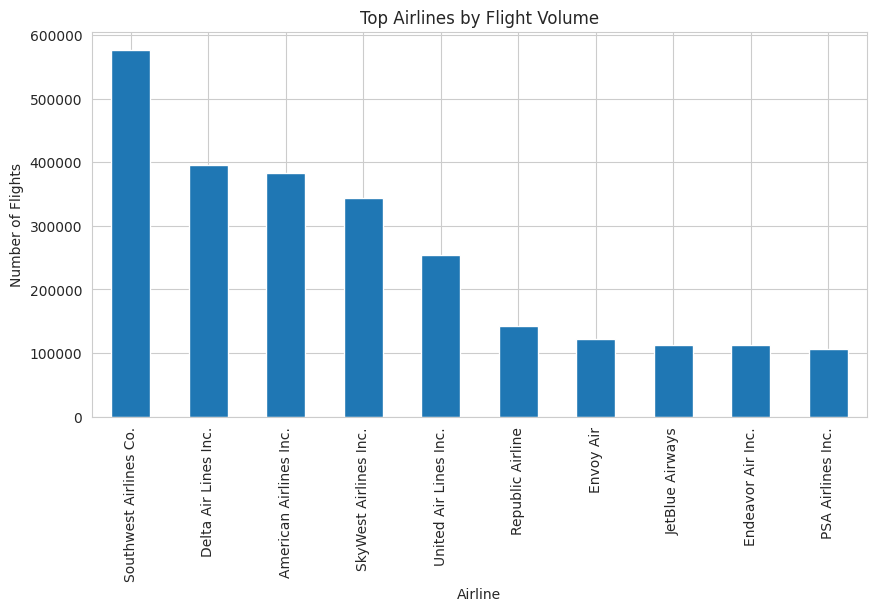

In [ ]:
plt.figure(figsize=(10,5))

df['AIRLINE'].value_counts().head(10).plot(kind='bar')

plt.title("Top Airlines by Flight Volume")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")

plt.show()

Observation:
The chart shows the top airlines based on flight volume.
Airlines with higher bars operate more flights, indicating larger operational networks.
This helps identify dominant airlines in the dataset.

**STEP 2: Airport Analysis (Busiest Airports)**

Find which airports have the highest flight departures.

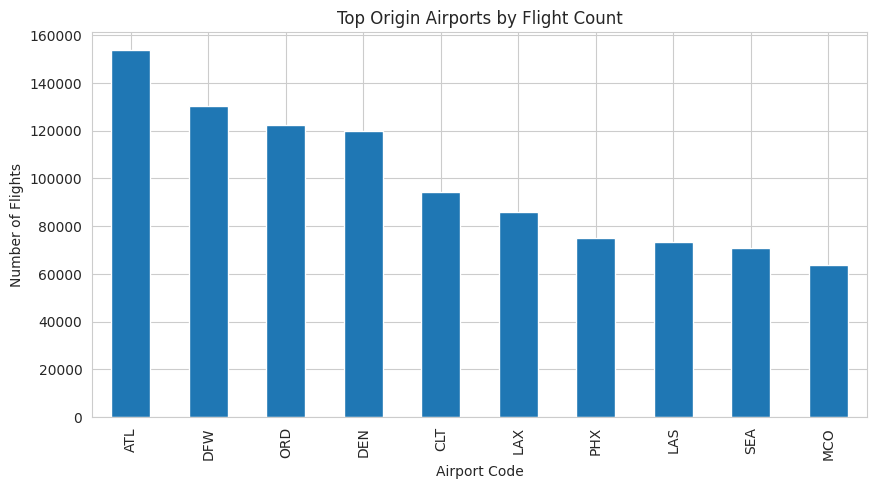

In [ ]:
plt.figure(figsize=(10,5))

df['ORIGIN'].value_counts().head(10).plot(kind='bar')

plt.title("Top Origin Airports by Flight Count")
plt.xlabel("Airport Code")
plt.ylabel("Number of Flights")

plt.show()

Observation:
Some airports handle significantly more flights than others.
These airports act as major hubs and may experience higher congestion.

**STEP 3: Monthly Flight Trends**

Check how flight activity changes across months

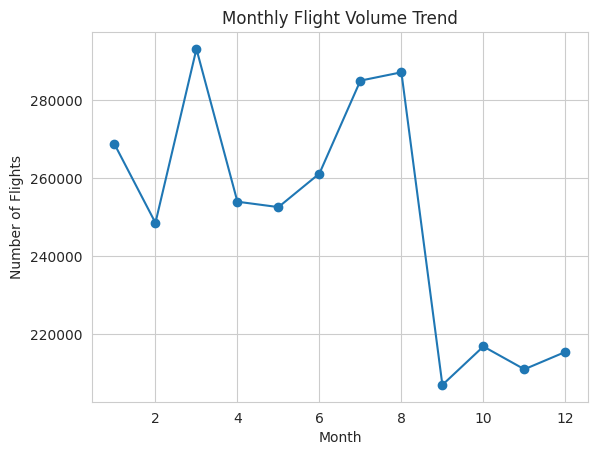

In [ ]:
monthly_flights = df.groupby('MONTH').size()

plt.figure()

monthly_flights.plot(kind='line', marker='o')

plt.title("Monthly Flight Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.show()

Observation:
Flight activity varies across months.
Higher peaks may indicate travel seasons or holidays.
Lower months indicate reduced demand periods.

**STEP 4: Hourly Flight Distribution**

Understand what time of day flights are most common.

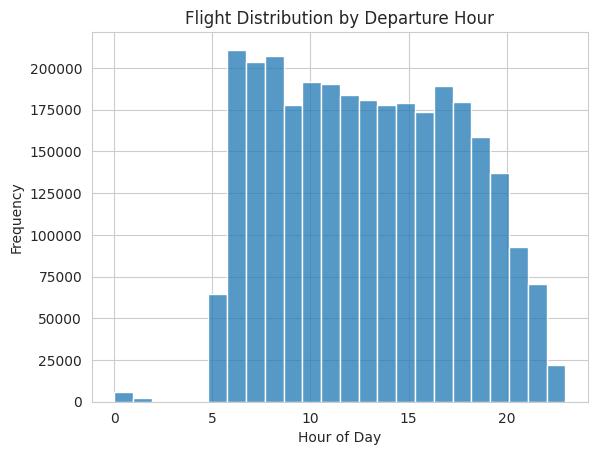

In [ ]:
plt.figure()

sns.histplot(df['DEP_HOUR'], bins=24)

plt.title("Flight Distribution by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")

plt.show()

Observation:
Flights are not evenly distributed throughout the day.
Certain hours show peak departure activity, usually morning and evening.
These time periods may correspond to higher airport congestion.

**STEP 5: Delay Distribution**

Analyze how delays are distributed.

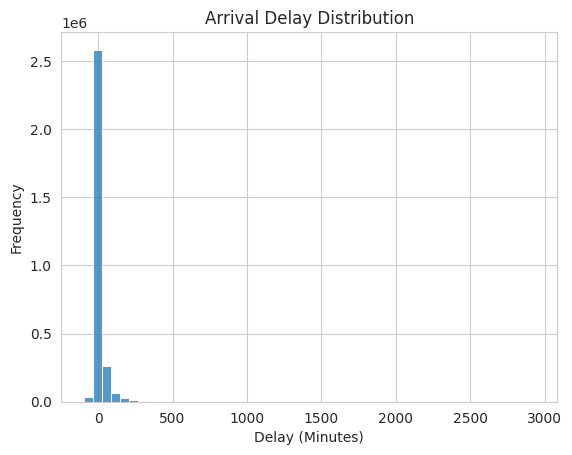

In [ ]:
plt.figure()

sns.histplot(df['ARR_DELAY'], bins=50)

plt.title("Arrival Delay Distribution")
plt.xlabel("Delay (Minutes)")
plt.ylabel("Frequency")

plt.show()

Observation:
Most flights experience small delays or arrive on time.
However, some flights have extreme delays creating a long tail in the distribution.

**STEP 6: Boxplot for Delay Spread**

Shows spread of delays and outliers.

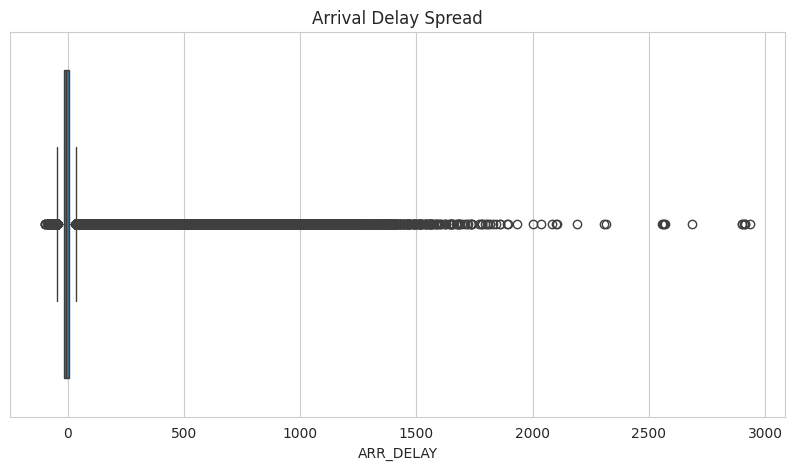

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['ARR_DELAY'])

plt.title("Arrival Delay Spread")

plt.show()

Observation:
The boxplot highlights the median delay and outliers.
Several extreme delays exist which may represent operational disruptions.

**STEP 7: Flights by Day of Week**

Check which days are busiest.

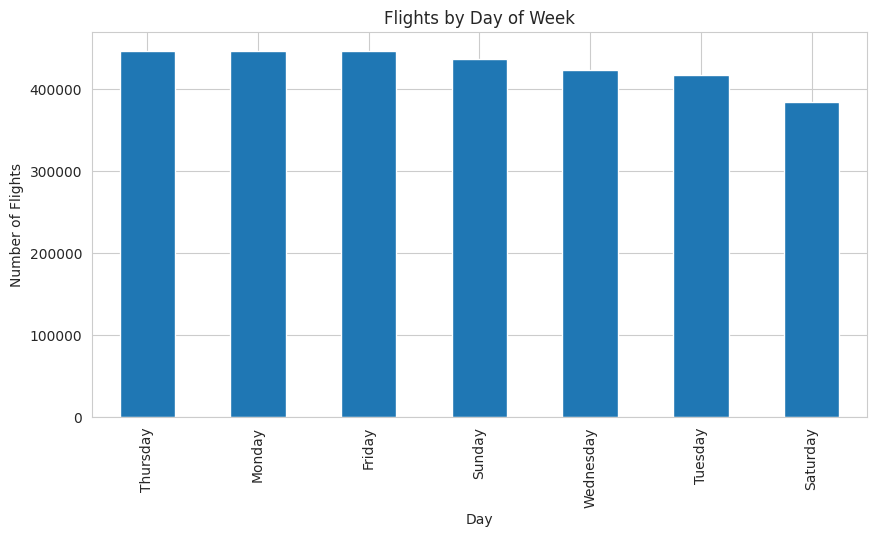

In [ ]:
plt.figure(figsize=(10,5))

df['DAY_NAME'].value_counts().plot(kind='bar')

plt.title("Flights by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Flights")

plt.show()

Observation:
Flight operations vary by weekday.
Some days show heavier traffic due to business travel or weekend tourism.

**STEP 8: Delay vs Not Delay (Using Delay Flag)**

Since you created IS_DELAYED.

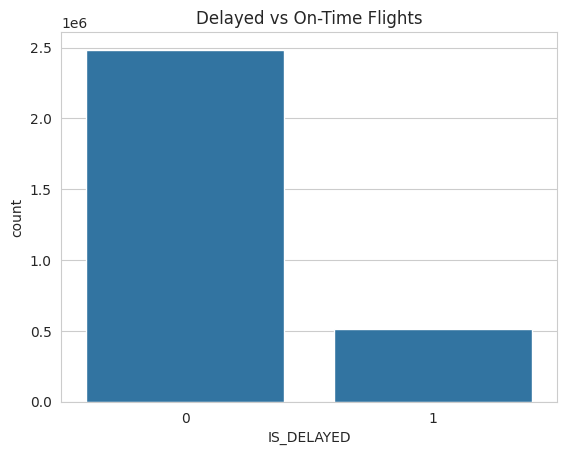

In [ ]:
plt.figure()

sns.countplot(x='IS_DELAYED', data=df)

plt.title("Delayed vs On-Time Flights")

plt.show()

Observation:
This visualization compares delayed flights versus on-time flights.
A high number of delayed flights may indicate operational inefficiencies.

# **✈️ WEEK 4 – DELAY CAUSE ANALYSIS**
Objective

Analyze different delay causes and understand which airlines, times, and airports contribute most to delays.

**STEP 1 – Delay Type Breakdown**

Airline delays come from multiple sources:

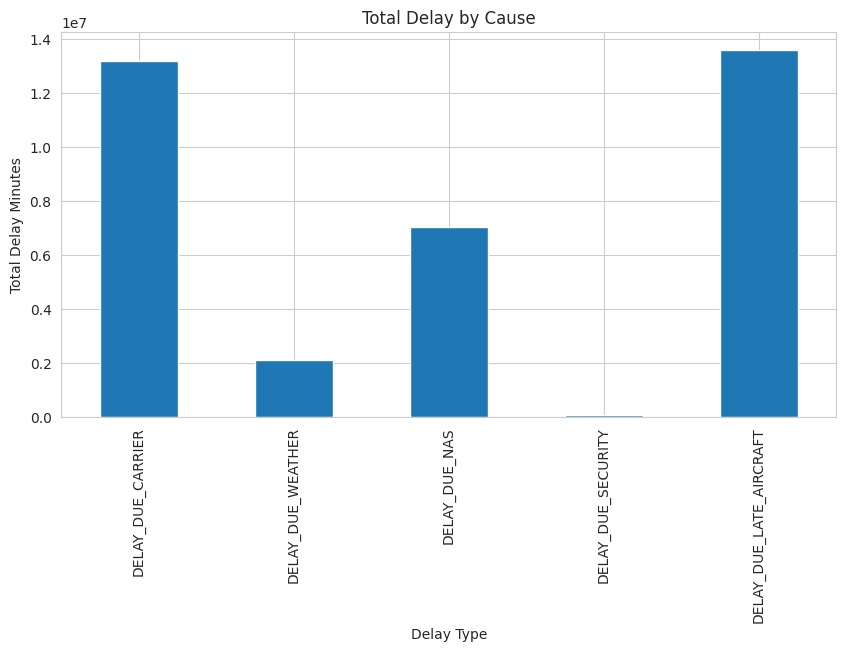

In [ ]:
delay_types = [
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

delay_sum = df[delay_types].sum()

plt.figure(figsize=(10,5))

delay_sum.plot(kind='bar')

plt.title("Total Delay by Cause")
plt.xlabel("Delay Type")
plt.ylabel("Total Delay Minutes")

plt.show()

Observation:
The chart shows the contribution of different delay causes.
Carrier and late aircraft delays often dominate, indicating operational issues.
Weather and security delays usually contribute less but may spike during disruptions.

**STEP 2 – Airline Comparison (Stacked Delay Chart)**

This shows how delay causes vary by airline.

/tmp/ipykernel_239/4142651667.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airline_delay = df.groupby('AIRLINE')[delay_types].mean().head(10)


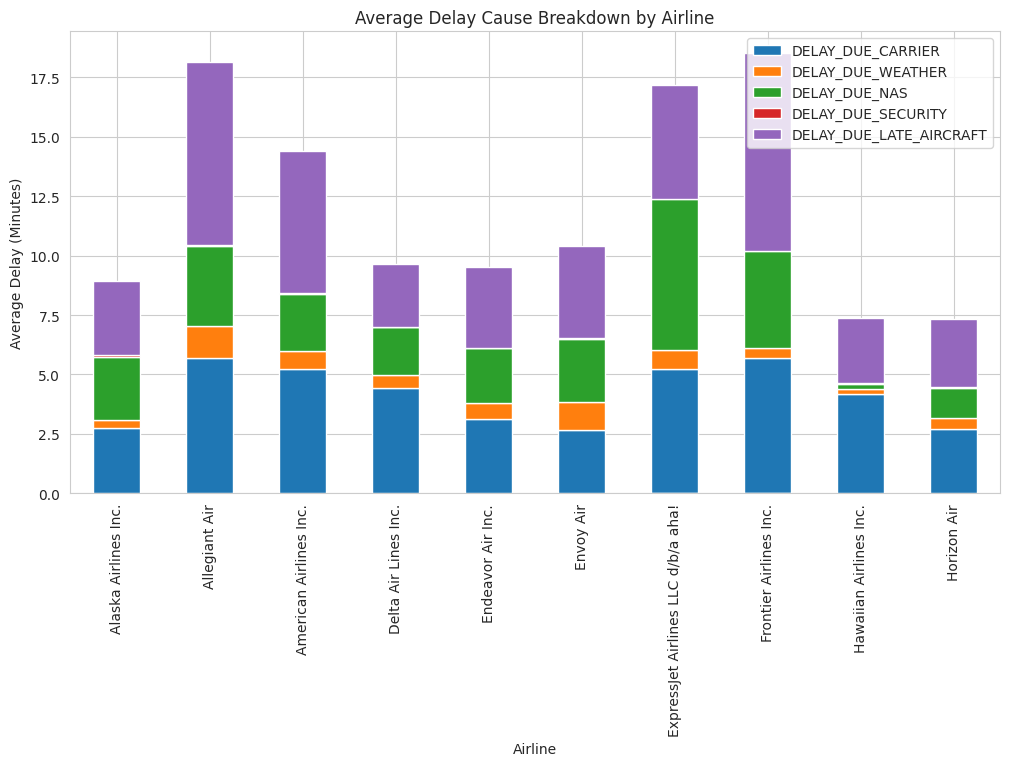

In [ ]:
airline_delay = df.groupby('AIRLINE')[delay_types].mean().head(10)

airline_delay.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Average Delay Cause Breakdown by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")

plt.show()

Observation:
Different airlines experience different types of delays.
Some airlines have higher carrier delays, while others experience more weather-related disruptions.
This indicates differences in operational efficiency.

**STEP 3 – Time Based Delay Trend**

This identifies when delays are more common during the day.

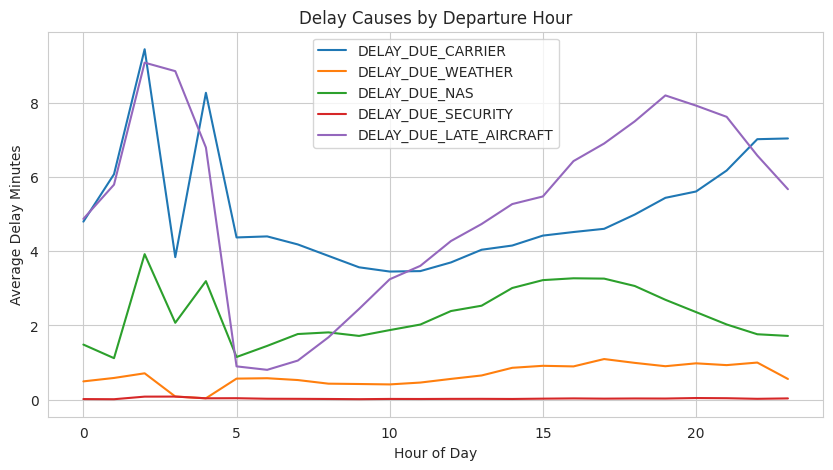

In [ ]:
hourly_delay = df.groupby('DEP_HOUR')[delay_types].mean()

hourly_delay.plot(
    kind='line',
    figsize=(10,5)
)

plt.title("Delay Causes by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay Minutes")

plt.show()

Observation:
Delays tend to increase during busy travel hours.
Late evening flights often accumulate delays due to earlier disruptions during the day.

**STEP 4 – Airport Delay Heatmap**

This identifies which airports experience higher delays.

/tmp/ipykernel_239/1382234314.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airport_delay = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(20)


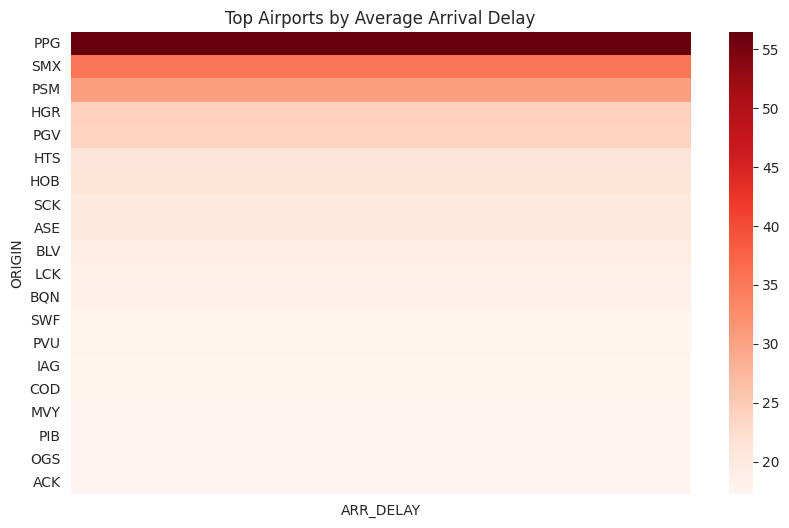

In [ ]:
airport_delay = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))

sns.heatmap(
    airport_delay.to_frame(),
    cmap="Reds",
    annot=False
)

plt.title("Top Airports by Average Arrival Delay")

plt.show()

Observation:
Some airports show consistently higher delays.
These airports may experience congestion, weather disruptions, or heavy traffic volumes.

**STEP 5 – Delay Percentage by Airline**

This shows which airlines have the highest percentage of delayed flights.

Code

/tmp/ipykernel_239/1566044453.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_rate = df.groupby('AIRLINE')['IS_DELAYED'].mean() * 100


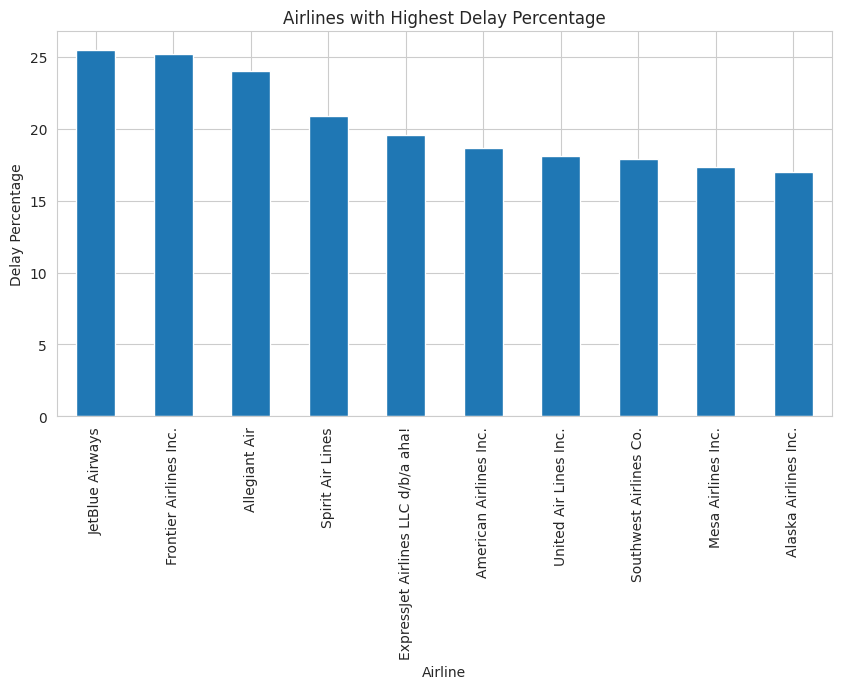

In [ ]:
delay_rate = df.groupby('AIRLINE')['IS_DELAYED'].mean() * 100

plt.figure(figsize=(10,5))

delay_rate.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Airlines with Highest Delay Percentage")
plt.xlabel("Airline")
plt.ylabel("Delay Percentage")

plt.show()

Observation:
Some airlines experience significantly higher delay rates.
This may reflect operational inefficiencies or route network complexity.

**STEP 6 – Delay Cause Correlation**

This checks relationships between delay types.

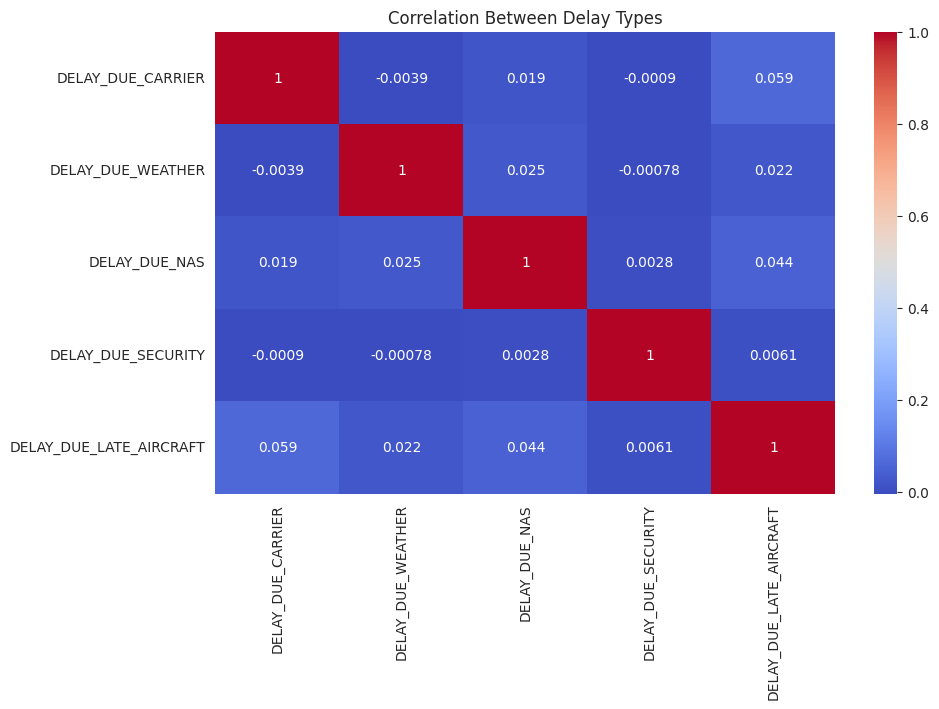

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[delay_types].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Delay Types")

plt.show()

Observation:
Certain delay types are correlated, suggesting cascading delays.
For example, late aircraft delays may lead to carrier delays later in the day.